# 4.1: Lines in $\mathbb{R}^3$

Let us briefly recall lines in the Euclidean plane -- the linear equation 
$$ y = ax + b$$
defines a line with slope $a$ with $y$-intercept $b$, i.e. it passes through the point $(0,b)$.

We want a similar description of lines in three-dimensional Euclidean space, and the language of vectors will help us do exactly that in this more general setting. We will see three different forms of lines in $\mathbb{R}^3$ -- vector form, parametric form, and symmetric form -- and return to the case of lines in $\mathbb{R}^2$ to see how it applies there too.

## Lines through the origin

Let's start with lines in $\mathbb{R}^3$ that go through the origin. Recall that lines can be viewed as a **span** of one vector $\vec v$, namely the collection of all scalar multiples of $\vec v$. In set-builder notation, the line is described as
$$ l = \left\{ t\vec v : t\in \mathbb{R}\right\}.$$
We simply say that the line $l$ is **spanned by** the vector $v$. Geometrically, this is the line through the origin that is _pointing at the direction of_, or _parallel to_, the vector $\vec v$. Here is a picture of the line $l$ spanned by the vector $v = \begin{bmatrix}1\\1\\1\end{bmatrix}$ which we have seen in lecture 2.

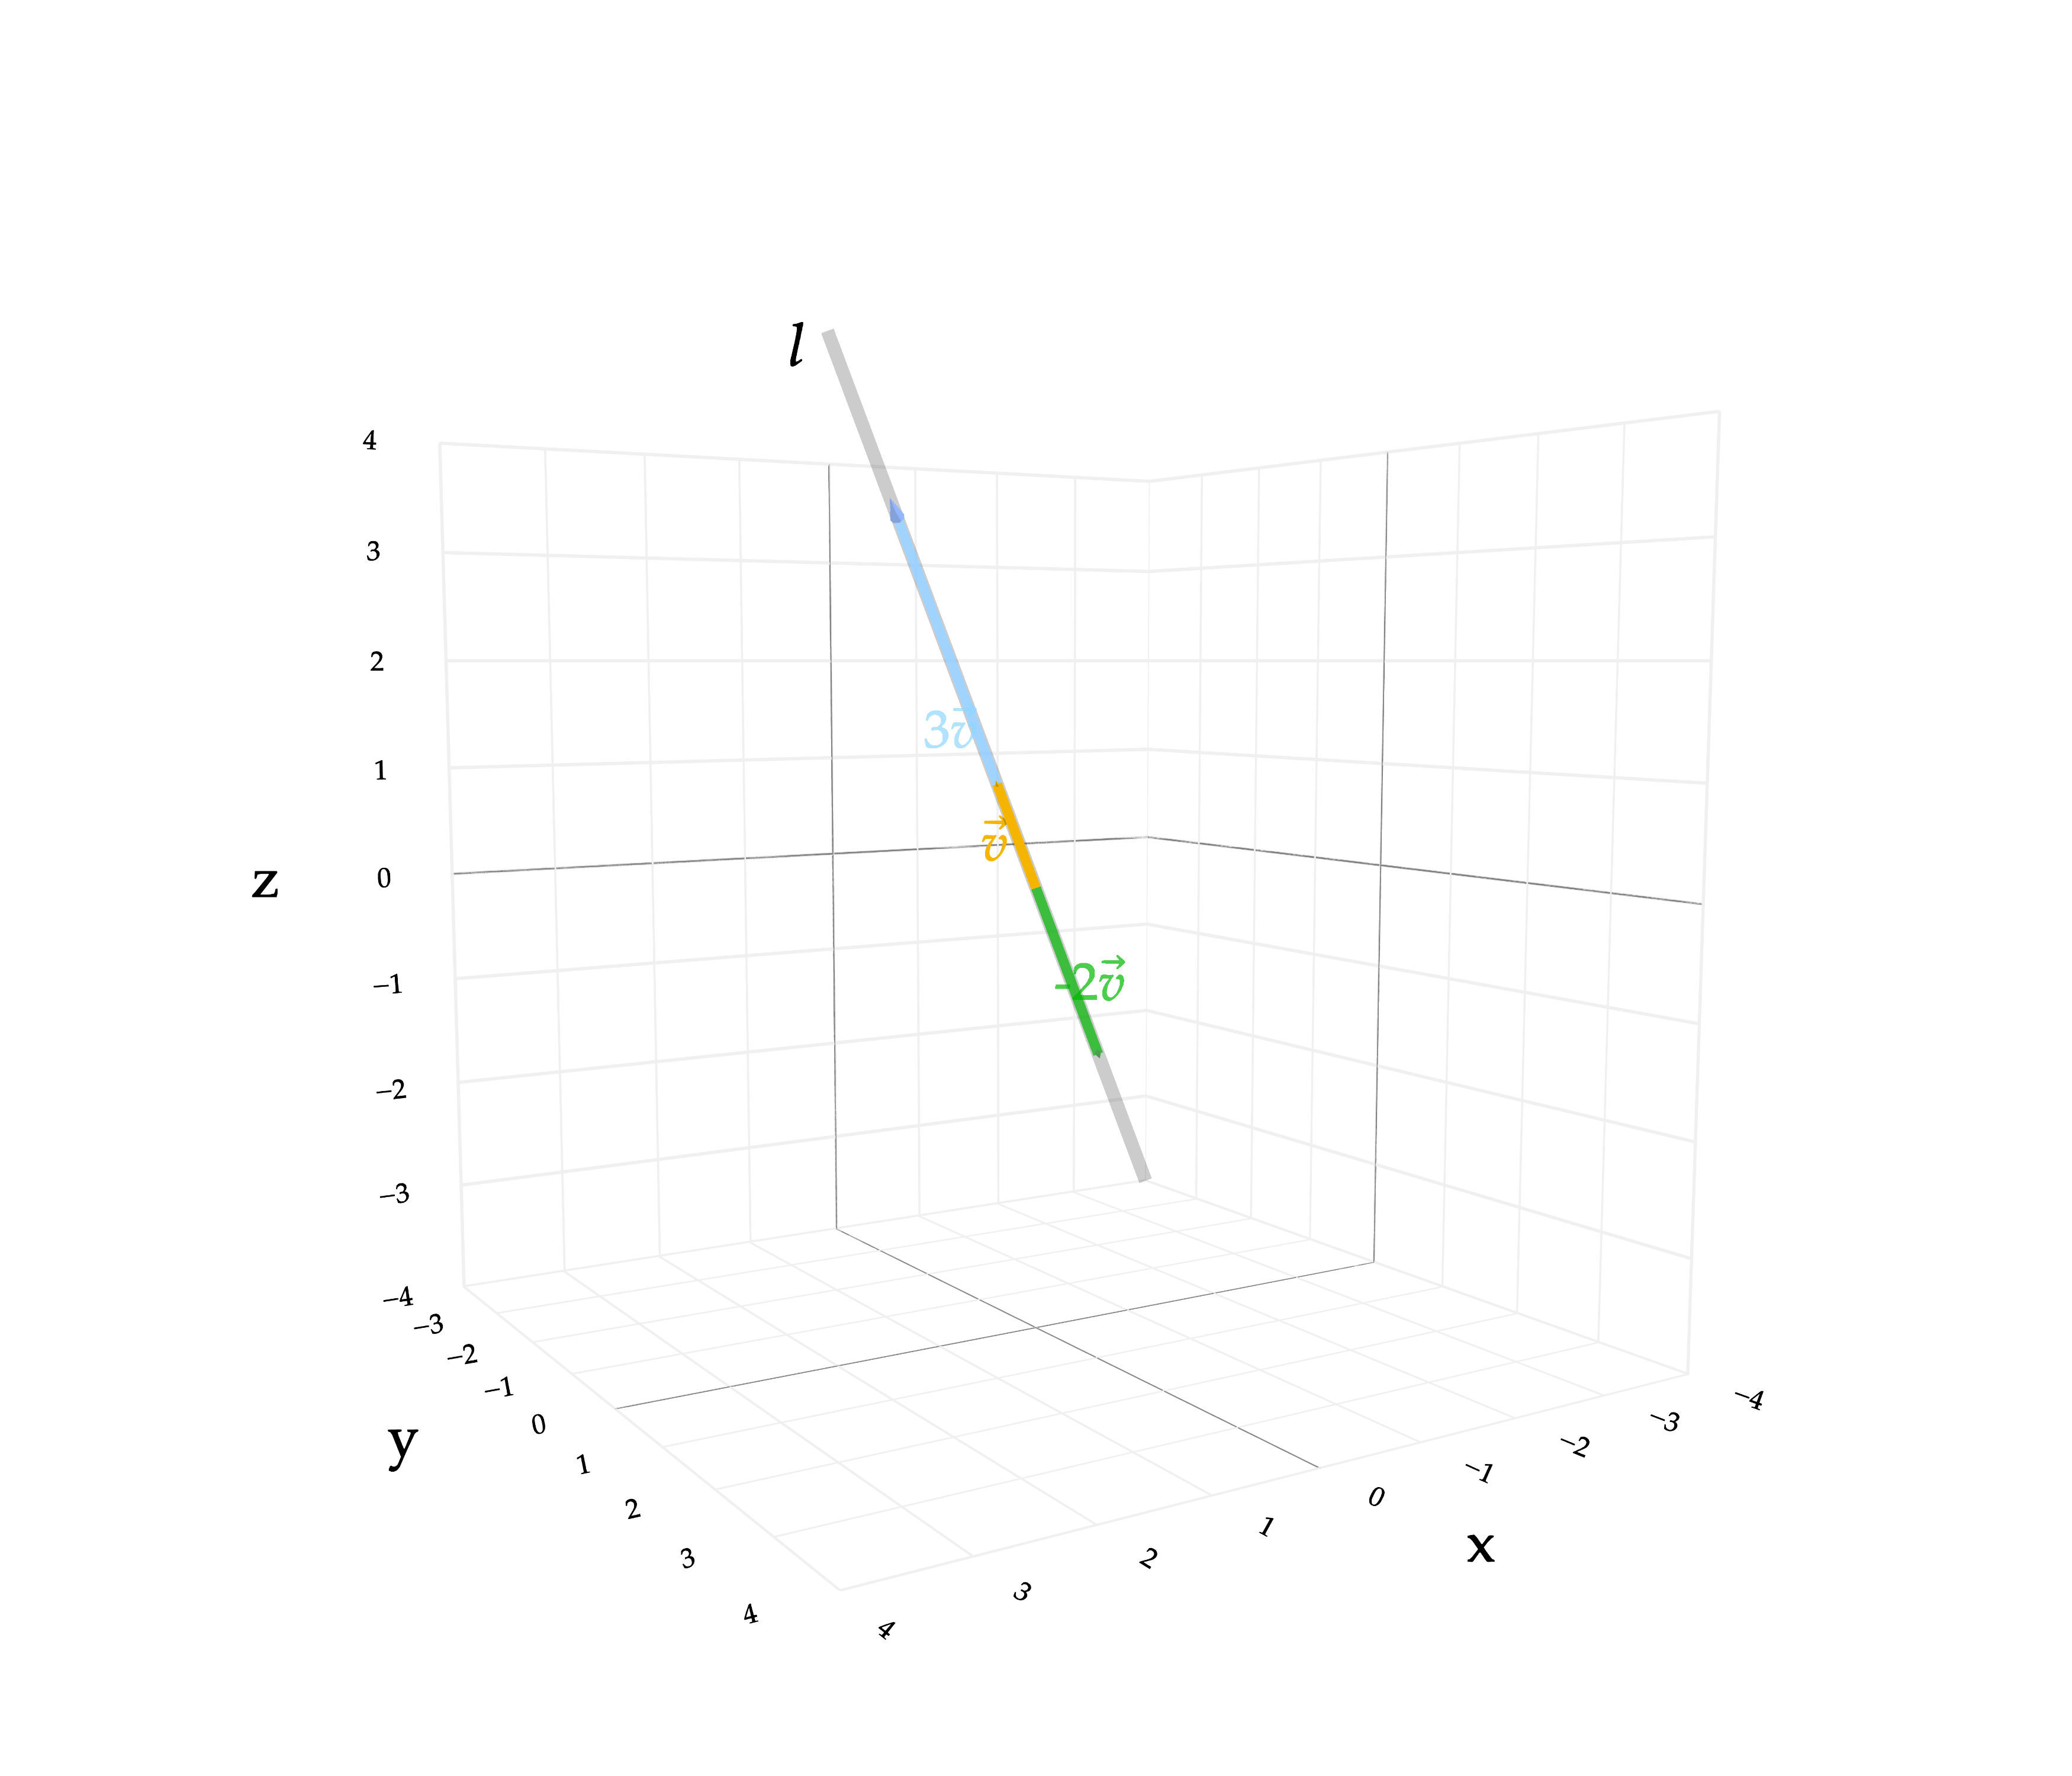

In [7]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image (Kaleido safe)
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# 1. Define the 3D vectors for v = (1, 1, 1)
# Start/end coordinates: (((x0, y0, z0), (x1, y1, z1)), color, label)
vectors = [
    (((0, 0, 0), (3, 3, 3)), 'rgba(100, 150, 250, 0.7)', '3<i>v</i>\u20D7'),     # 3v (transparent blue)
    (((0, 0, 0), (-2, -2, -2)), 'rgba(0, 128, 0, 0.7)', '-2<i>v</i>\u20D7'),      # -2v (transparent green)
    (((0, 0, 0), (1, 1, 1)), '#f4b400', '<i>v</i>\u20D7')                         # The original vector v (solid gold)
]

# Create the figure
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4, vdeltaz=0.4)

# 2. Add the continuous solid line representing the span in 3D
# The line represents the parametric equation x=t, y=t, z=t
# Changed to a thick, transparent black line
fig.add_trace(go.Scatter3d(
    x=[-5, 4],
    y=[-5, 4],
    z=[-5, 4],
    mode='lines',
    line=dict(color='rgba(0, 0, 0, 0.2)', width=8), 
    showlegend=False,
    hoverinfo='skip'
))

# 3. FIX THE CLUTTER (Z-Ordering)
# Push the line to the absolute back so it rests beneath the 3D arrows
fig.data = (fig.data[-1],) + fig.data[:-1]

# 4. Explicitly label the line 'l'
# Positioned at (3.5, 3.5, 3.5) so it remains inside the [-4, 4] grid and visible
fig.add_trace(go.Scatter3d(
    x=[3.5], y=[3.5], z=[3.5],  
    mode='text',
    text=['<i>l</i>'],
    textfont=dict(size=18, color='black'),
    textposition='top left',
    showlegend=False,
    hoverinfo='skip'
))

# 5. Format the layout
# Set aspect ratio to a perfect cube (1:1:1) and explicitly add axis titles
fig.update_layout(
    width=700, 
    height=600,
    scene=dict(
        xaxis=dict(range=[-4, 4], dtick=1, title='x'),
        yaxis=dict(range=[-4, 4], dtick=1, title='y'),
        zaxis=dict(range=[-4, 4], dtick=1, title='z'),
        aspectratio=dict(x=1, y=1, z=1) 
    )
)

fig.show(scale=5)

### The three forms

More generally, we can take any vector $ \vec v = \begin{bmatrix} a\\b\\c \end{bmatrix}$ and consider the line $l$ spanned by $\vec v$, i.e. the line pointing in the direction of $\vec v$. Naturally we call $\vec v$ the **direction vector** of line $l$.


How would one express a vector $\vec r = \begin{bmatrix}x\\ y\\ z\end{bmatrix}$ on the line spanned by $\vec v$? In other words, how can I write down an _equation_ for the vector $\vec r$ that describes the line? Since $\vec r$ is in the span of $\vec v$, there must be some scalar $t$ such that
$$ \vec r = t\vec v.$$


This is the **vector-parametric form** of the equation of the line spanned by $\vec v$. If we expand the expression component-wise, we obtain:
$$ \begin{cases} x = ta \\ y = tb \\ z = tc \end{cases}.$$
This is the **scalar-parametric form** of the equation of line, since we have an equation for each $x,y,z$ coordinate depending on a _parameter_ $t$. If we would not like to see the parameter, we can solve for $t$ and obtain the following expressions for $t$:
$$ \frac{x}{a} = \frac{y}{b} = \frac{z}{c}.$$
This is the **symmetric form** of the equation.

A technical point: We have to be careful with the symmetric form whenever one of $a$, $b$, $c$ is zero since we cannot divide by zero. For instance, let us suppose that $a=0$ and convert from parametric form to symmetric form. The parametric form is given by
$$ x = t\cdot 0 = 0,\ y = tb,\ z = tc.$$
Cancelling out the parameter $t$, the symmetric form is thus written as
$$ x = 0,\ \frac{y}{b} = \frac{z}{c}.$$

## Affine lines

In general, not all lines in $\mathbb{R}^3$ need to go through the origin! We call them **affine lines** to emphasize that they may not necessarily pass through the origin. As we did above, let us study the three different forms of equations for affine lines.

An affine line $l$ is described by two pieces of information:
* the direction vector $\vec v$ in which it is pointing;
* the position vector $\vec p$ of a point which it goes through.

Let us describe this setting with the following picture:

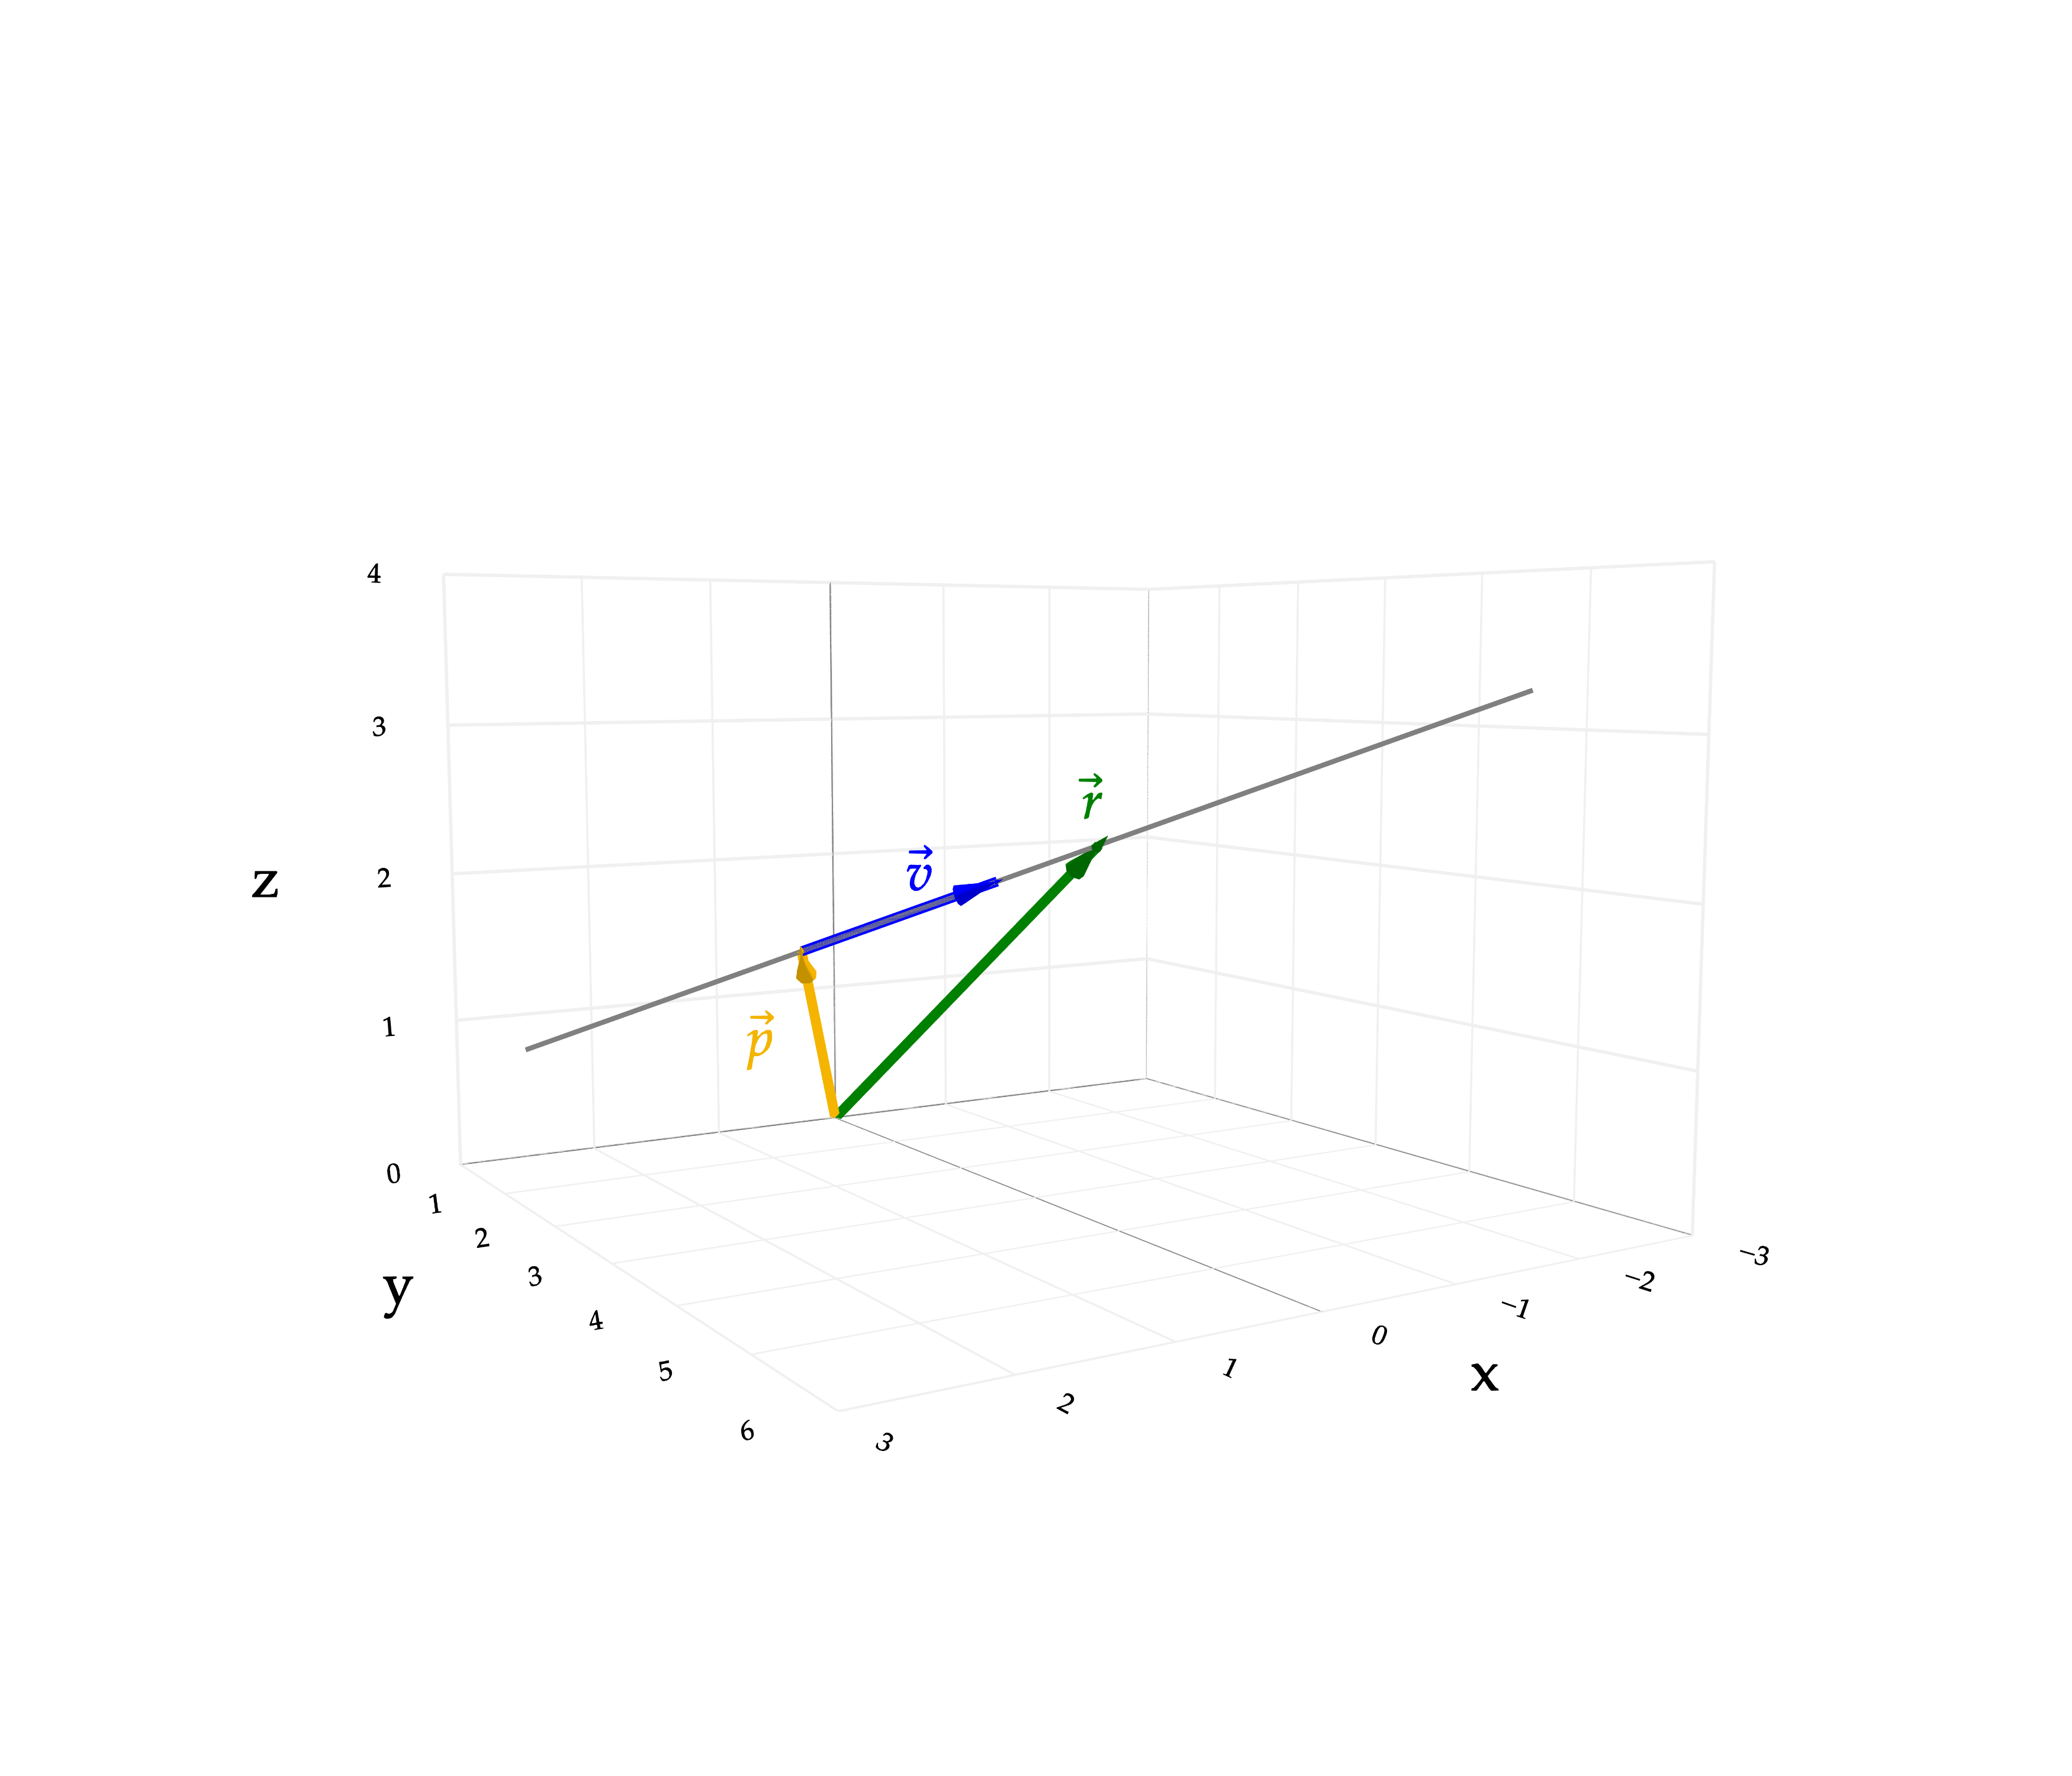

In [19]:
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"

# ---
from utils import plot_vectors_non_origin

# Define the exact same coordinates
O = (0, 0, 0)
P = (1, 1.5, 1.5)             
V_tip = (0, 2.5, 2.0)         
R = (-0.5, 3.0, 2.25)         

# 1. REMOVE AUTOMATIC LABELS: Pass empty strings as the third argument
vectors = [
    ((O, P), '#f4b400', ''),                 
    ((P, V_tip), 'blue', ''),                
    ((O, R), 'green', '')                    
]

# Generate the base lines (vdelta values no longer matter since labels are empty)
fig = plot_vectors_non_origin(vectors, vdeltax=0, vdeltay=0, vdeltaz=0)

# ENHANCE ARROWHEADS WITH 3D CONES (Same as before)
fig.add_trace(go.Cone(
    x=[P[0]], y=[P[1]], z=[P[2]],
    u=[P[0]-O[0]], v=[P[1]-O[1]], w=[P[2]-O[2]],
    sizemode="absolute", sizeref=0.3, anchor="tip",
    colorscale=[[0, '#f4b400'], [1, '#f4b400']], showscale=False, hoverinfo='skip'
))
fig.add_trace(go.Cone(
    x=[V_tip[0]], y=[V_tip[1]], z=[V_tip[2]],
    u=[V_tip[0]-P[0]], v=[V_tip[1]-P[1]], w=[V_tip[2]-P[2]],
    sizemode="absolute", sizeref=0.3, anchor="tip",
    colorscale=[[0, 'blue'], [1, 'blue']], showscale=False, hoverinfo='skip'
))
fig.add_trace(go.Cone(
    x=[R[0]], y=[R[1]], z=[R[2]],
    u=[R[0]-O[0]], v=[R[1]-O[1]], w=[R[2]-O[2]],
    sizemode="absolute", sizeref=0.3, anchor="tip",
    colorscale=[[0, 'green'], [1, 'green']], showscale=False, hoverinfo='skip'
))

# 2. MANUAL LABEL POSITIONING
# Define the exact coordinates where you want the text to float
label_x = [1.2, 0.5, -0.3]  # x-coordinates for p, v, r
label_y = [1.2, 2.3, 3.2]    # y-coordinates for p, v, r
label_z = [0.3, 1.6, 2.1]    # z-coordinates for p, v, r
label_text = ['<i>p</i>\u20D7', '<i>v</i>\u20D7', '<i>r</i>\u20D7']
label_colors = ['#f4b400', 'blue', 'green']

fig.add_trace(go.Scatter3d(
    x=label_x, 
    y=label_y, 
    z=label_z,
    mode='text',
    text=label_text,
    textfont=dict(color=label_colors, size=16),
    showlegend=False,
    hoverinfo='skip'
))

# Draw the Affine Line L
t_vals = np.array([-1.5, 3.5])
fig.add_trace(go.Scatter3d(
    x=1 + t_vals * (-1), 
    y=1.5 + t_vals * 1, 
    z=1.5 + t_vals * 0.5,
    mode='lines',
    line=dict(color='gray', width=3),
    showlegend=False,
    hoverinfo='skip'
))

# Format the 3D layout
fig.update_layout(
    width=700, height=600,
    scene=dict(
        xaxis=dict(range=[-3, 3], dtick=1),
        yaxis=dict(range=[0, 6], dtick=1),
        zaxis=dict(range=[0, 4], dtick=1),
        aspectratio=dict(x=1, y=1, z=0.7)
    )
)

fig.show(scale=5)

The position vector for a general point on the line $l$ is denoted by $\vec r$. Note that the vector $\vec r - \vec p$, by using the geometric interpretation of vector subtraction using triangles, is parallel to the vector $\vec v$. Hence there is a scalar $t$ such that
$$ \vec r - \vec p = t\vec v.$$
Therefore we obtain the **vector-parametric form** of the equation of this affine line as
$$ \vec r = \vec p + t\vec v.$$
Let us substitute
$$\vec r = \begin{bmatrix} x \\ y \\ z\end{bmatrix},\ \vec p = \begin{bmatrix} x_0 \\ y_0 \\ z_0\end{bmatrix},\ \vec v = \begin{bmatrix} a\\ b\\c\end{bmatrix}$$
into the vector form of the equation and equate each entry. This gives us the **scalar-parametric form**:
$$ \begin{cases} x = x_0 + at \\ y = y_0 + bt \\ z = z_0 + ct\end{cases}. $$
If we wish to not use the parameter $t$, we can write use the **symmetric form** by solving by $t$:
$$ \frac{x - x_0}{a} = \frac{y - y_0}{b} = \frac{z - z_0}{c}.$$

Again one must be careful when writing the symmetric form, in the same way we did previously, whenever one of $a,b,c$ is zero.